# RNN (Özyinelemeli sinir ağları)

Dizi şeklindeki veriler(zaman serileri, doğal dil işleme problemlerindeki metinler gibi) için çalışmak üzere tasarlanmış özel bir yapay sinir ağı türüdür. Burada geçmişe dönme var.

![rnn-mimari](rnn_mimari.png)

# RNN ile Havayolu Yolcu Sayısı Tahmini
1. İş problemi
2. Veriyi anlama
3. Veriyi hazırlama
4. Modelleme
5. Değerlendirme

In [1]:
# Veriyi okuma ve işleme adımında kullanılacak olan kütüphaneler
import numpy as np
import pandas as pd
import datetime as df
import tensorflow as tf
import matplotlib.pyplot as plt

# Model değerlendirme ve veriyi scale edebilmemiz için kullanılacak olan kütüphaneler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Model için kullanılacak olan kütüphaneler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Uyarıları kapatmak için kullanılacak kütüphane
import warnings
warnings.filterwarnings("ignore")

# Tensorflow warning engelleme
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-05-02 16:07:42.785136: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("international-airline-passengers.csv")
df.head()

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


## 2. Veriyi anlama

In [3]:
# İkinci sütunun adı çok uzun. Değiştirelim
df.columns

Index(['Month', 'International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60'], dtype='object')

In [4]:
df.columns = ["Month", "Passengers"]
df.head()

,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [5]:
df.tail()

,Month,Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [6]:
df.shape

(145, 2)

In [7]:
df.dtypes # Month işimize yarayacak formatta değil.

Month          object
Passengers    float64
dtype: object

In [8]:
df.isnull().sum()

Month         0
Passengers    1
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


## 3. Veriyi hazırlama

In [10]:
df = df[:144]
df.tail()

,Month,Passengers
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [11]:
df["Month"] = pd.to_datetime(df["Month"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB


In [13]:
print("Minimum tarih: ", df["Month"].min())
print("Maximum tarih: ", df["Month"].max())

Minimum tarih:  1949-01-01 00:00:00
Maximum tarih:  1960-12-01 00:00:00


Month sütunu index olarak atayalım.

In [14]:
df.index = df["Month"]

In [15]:
df.drop("Month", axis = 1, inplace= True)

In [16]:
df.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [17]:
result_df = df.copy()

<Axes: title={'center': 'Aylık Yolcu Sayısı'}, xlabel='Month'>

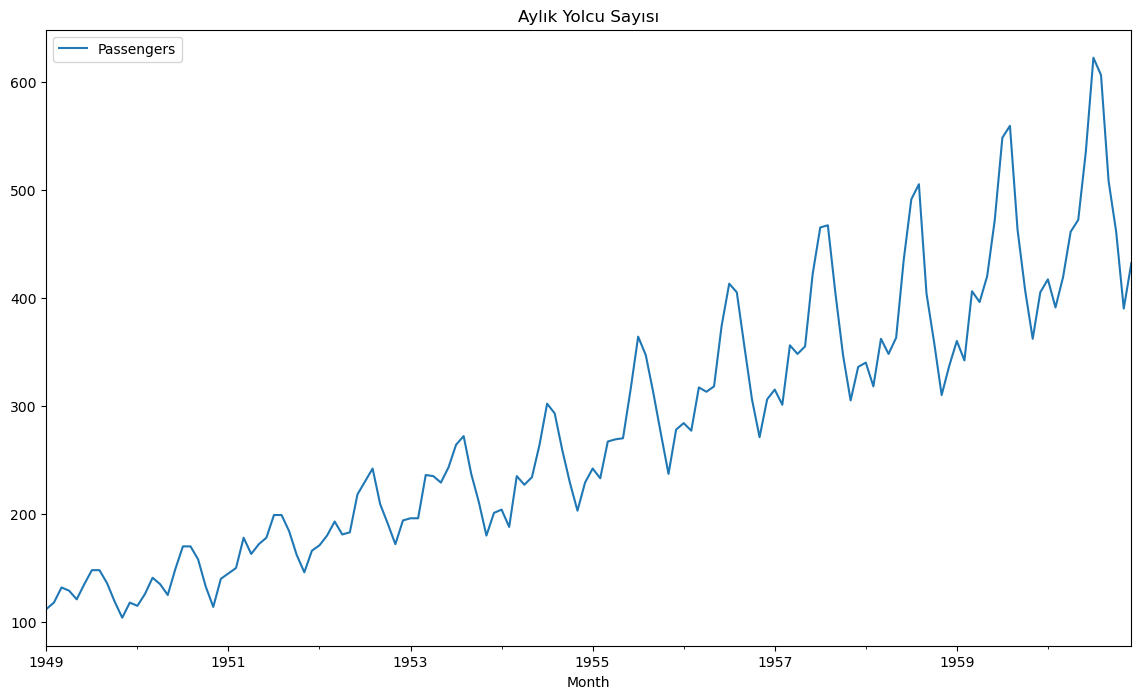

In [18]:
df.plot(figsize = (14, 8), title = "Aylık Yolcu Sayısı")

In [19]:
data = df["Passengers"].values

In [20]:
data[0:5]

array([112., 118., 132., 129., 121.])

In [21]:
type(data[0:5])

numpy.ndarray

In [22]:
type(data[0])

numpy.float64

In [23]:
data = data.astype("float32")

In [24]:
type(data[0])

numpy.float32

In [25]:
data.shape

(144,)

In [26]:
data = data.reshape(-1, 1) # tek boyuta indirgedik

In [27]:
data.shape

(144, 1)

In [28]:
def split_data(dataframe, test_size):
    position = int(round(len(dataframe) * (1 - test_size)))
    train = dataframe[:position]
    test = dataframe[position:]
    return train, test, position

In [29]:
train, test, position = split_data(data, 0.33)

In [30]:
print(train.shape, test.shape)

(96, 1) (48, 1)


In [31]:
scaler_train = MinMaxScaler(feature_range= (0, 1))
train = scaler_train.fit_transform(train)

In [32]:
scaler_test = MinMaxScaler(feature_range= (0 ,1))
test = scaler_test.fit_transform(test)

In [33]:
train[0:5]

array([[0.02588999],
       [0.04530746],
       [0.09061491],
       [0.08090615],
       [0.05501619]], dtype=float32)

Her bir feature kendinden bir önceki featureden etkilenir ve biz bunu bağımsız değişken olarak kullanacağız.

In [34]:
def create_features(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        Y.append(data[i, 0])

    return np.array(X), np.array(Y)

In [35]:
lookback = 1 # birim geriye git

In [36]:
X_train, y_train = create_features(train, lookback)

In [37]:
X_test, y_test = create_features(test, lookback)

In [38]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(95, 1) (95,) (47, 1) (47,)


RNN gridi olarak üç boyutlu veri istiyor. O yüzden dönüştürelim.

In [39]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [40]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(95, 1, 1) (95, 1) (47, 1, 1) (47, 1)


## 4. Modelleme

In [41]:
# Modelin dış iskelertini(mimarisini) oluşturalım
model = Sequential()

model.add(SimpleRNN(units= 50, activation= "relu", input_shape = (X_train.shape[1], lookback)))
model.add(Dropout(0.2))
model.add(Dense(1))

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# İç modeli de ayatrlayalım
# Optimizasyon ve değerlendirme metriklerini ayatlayalım
model.compile(loss = "mean_squared_error", optimizer = "adam")

In [44]:
callbacks = [EarlyStopping(monitor = "val_loss", patience = 3, verbose =1, mode = "min"),
            ModelCheckpoint(filepath= "model.keras", monitor = "val_loss", mode = "min", save_best_only= True,
                           save_weights_only= False, verbose = 1)]

In [45]:
history = model.fit(x = X_train, y = y_train, epochs = 50, batch_size = 50, validation_data= (X_test, y_test),
                     callbacks= callbacks, shuffle= False)

Epoch 1/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - loss: 0.0366
Epoch 1: val_loss improved from inf to 0.13744, saving model to model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - loss: 0.1111 - val_loss: 0.1374
Epoch 2/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0351
Epoch 2: val_loss improved from 0.13744 to 0.12814, saving model to model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0965 - val_loss: 0.1281
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0304
Epoch 3: val_loss improved from 0.12814 to 0.11924, saving model to model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0872 - val_loss: 0.1192
Epoch 4/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0276
Epoch 4: val_loss improved from 0.11924 to 0.11079, saving model to model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0852 - val_loss: 0.1108
Epoch 5/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0248
Epoch 5: val_loss improved from 0.11079 to 0.10278, saving model to model.ker

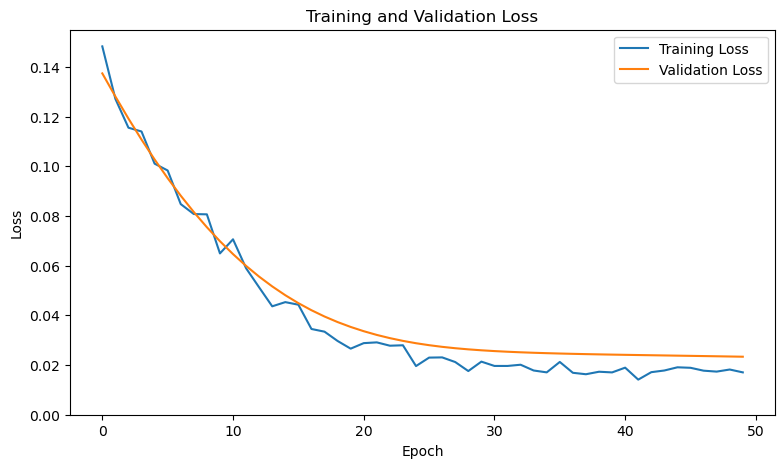

In [46]:
plt.figure(figsize= (20, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.legend(loc = "upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim([0, max(plt.ylim())])
plt.title("Training and Validation Loss")
plt.show()

## 5. Değerlendirme

In [47]:
loss = model.evaluate(X_test, y_test, batch_size=1)
print("Train loss:", (100 * loss))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0203
Train loss: 2.3356933146715164


In [48]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [49]:
train_predict = scaler_train.inverse_transform(train_predict)
test_predict = scaler_test.inverse_transform(test_predict)

In [50]:
y_train = scaler_train.inverse_transform(y_train)
y_test = scaler_test.inverse_transform(y_test)

In [51]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))

In [52]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

In [53]:
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 35.09311294555664
Test RMSE: 49.058345794677734


In [54]:
train_prediction_df = result_df[lookback:position]
train_prediction_df["Prediction"] = train_predict

In [55]:
test_prediction_df = result_df[position + lookback:]
test_prediction_df["Prediction"] = test_predict

In [56]:
train_prediction_df.head(5)

,Passengers,Prediction
Month,,
1949-02-01,118.0,157.266876
1949-03-01,132.0,161.459778
1949-04-01,129.0,171.416779
1949-05-01,121.0,169.282654
1949-06-01,135.0,163.591614


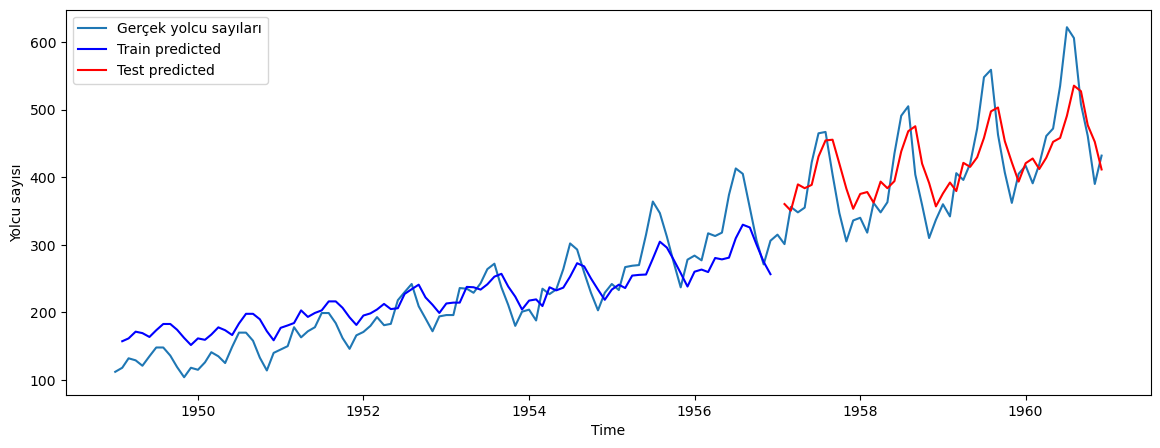

In [57]:
# Train ve test tahminlerini görselleştirelim
plt.figure(figsize= (14, 5))
plt.plot(result_df, label = "Gerçek yolcu sayıları")
plt.plot(train_prediction_df["Prediction"], color = "blue",label = "Train predicted")
plt.plot(test_prediction_df["Prediction"], color = "red",label = "Test predicted")
plt.xlabel("Time")
plt.ylabel("Yolcu sayısı")
plt.legend()
plt.show()